In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

# Settings
os.chdir('/Users/cirrus/Desktop/PMOS_PROJECT/notebook')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 120

print('All libraries imported')
print(f'   TensorFlow : {tf.__version__}')
print(f'   GPU        : {tf.config.list_physical_devices("GPU")}')


Mounted at /content/drive
✅ Libraries imported
   TensorFlow : 2.20.0
   GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Local adaptation note.** This block was developed on Colab against a Google Drive copy of the ultrasound set (`ovarian_ultrasound_dataset/{Normal,PCO,Dominant_Follicle}`, 304 images total). That dataset is not committed to this repo — `notebook/data/` only ships the Excel workbook — so this notebook cannot be run end-to-end as-is. Drop the three class folders under `notebook/data/ovarian_ultrasound_dataset/` to run it locally. The `pmos_cnn_final.keras` already in `artifacts/` was produced by a run of this notebook (or one very close to it); re-running it will overwrite that file with a new training run, which will not be bit-identical since MobileNetV2 fine-tuning and `ImageDataGenerator` augmentation are not fully seeded.

### Cell 2 — Define Paths & Count Images

In [3]:
# Paths
BASE_DIR = os.path.join('data', 'ovarian_ultrasound_dataset')

CLASSES = ['Normal', 'PCO', 'Dominant_Follicle']

# Constants
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16          # small batch - small dataset
EPOCHS     = 50          # more epochs - small dataset needs more
NUM_CLASSES = 3

print('=== DATASET OVERVIEW ===')
total = 0
for cls in CLASSES:
    path = os.path.join(BASE_DIR, cls)
    count = len(os.listdir(path))
    total += count
    print(f'  {cls:20s}: {count} images')
print(f'  {"Total":20s}: {total} images')

print(f'\n=== CONFIGURATION ===')
print(f'  Image size : {IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Epochs     : {EPOCHS}')
print(f'  Classes    : {NUM_CLASSES}')


=== DATASET OVERVIEW ===
  Normal              : 42 images
  PCO                 : 117 images
  Dominant_Follicle   : 145 images
  Total               : 304 images

=== CONFIGURATION ===
  Image size : (224, 224)
  Batch size : 16
  Epochs     : 50
  Classes    : 3


### Cell 3 — Split Dataset into Train/Val/Test

In [4]:
import shutil
from sklearn.model_selection import train_test_split

# Create split directories
SPLIT_DIR = os.path.join('outputs', 'ovarian_split')

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

# Split each class 70/15/15
print('=== SPLITTING DATASET ===')
for cls in CLASSES:
    src = os.path.join(BASE_DIR, cls)
    images = os.listdir(src)

    # 70% train, 15% val, 15% test
    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test   = train_test_split(temp,   test_size=0.5, random_state=42)

    for img in train:
        shutil.copy(os.path.join(src, img), os.path.join(SPLIT_DIR, 'train', cls, img))
    for img in val:
        shutil.copy(os.path.join(src, img), os.path.join(SPLIT_DIR, 'val', cls, img))
    for img in test:
        shutil.copy(os.path.join(src, img), os.path.join(SPLIT_DIR, 'test', cls, img))

    print(f'  {cls:20s}: train={len(train)} val={len(val)} test={len(test)}')

TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')

print('\nDataset split complete')

=== SPLITTING DATASET ===
  Normal              : train=29 val=6 test=7
  PCO                 : train=81 val=18 test=18
  Dominant_Follicle   : train=101 val=22 test=22

✅ Dataset split complete


#### Cell 4 — Data Generators with Augmentation

In [5]:
# Training — WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Val and Test — NO augmentation, only normalize
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Data generators created')
print(f'   Train : {train_generator.samples} images')
print(f'   Val   : {val_generator.samples} images')
print(f'   Test  : {test_generator.samples} images')
print(f'   Class indices: {train_generator.class_indices}')

Found 210 images belonging to 3 classes.
Found 45 images belonging to 3 classes.
Found 46 images belonging to 3 classes.
✅ Data generators created
   Train : 210 images
   Val   : 45 images
   Test  : 46 images
   Class indices: {'Dominant_Follicle': 0, 'Normal': 1, 'PCO': 2}


### Cell 5 — Visualise Sample Images

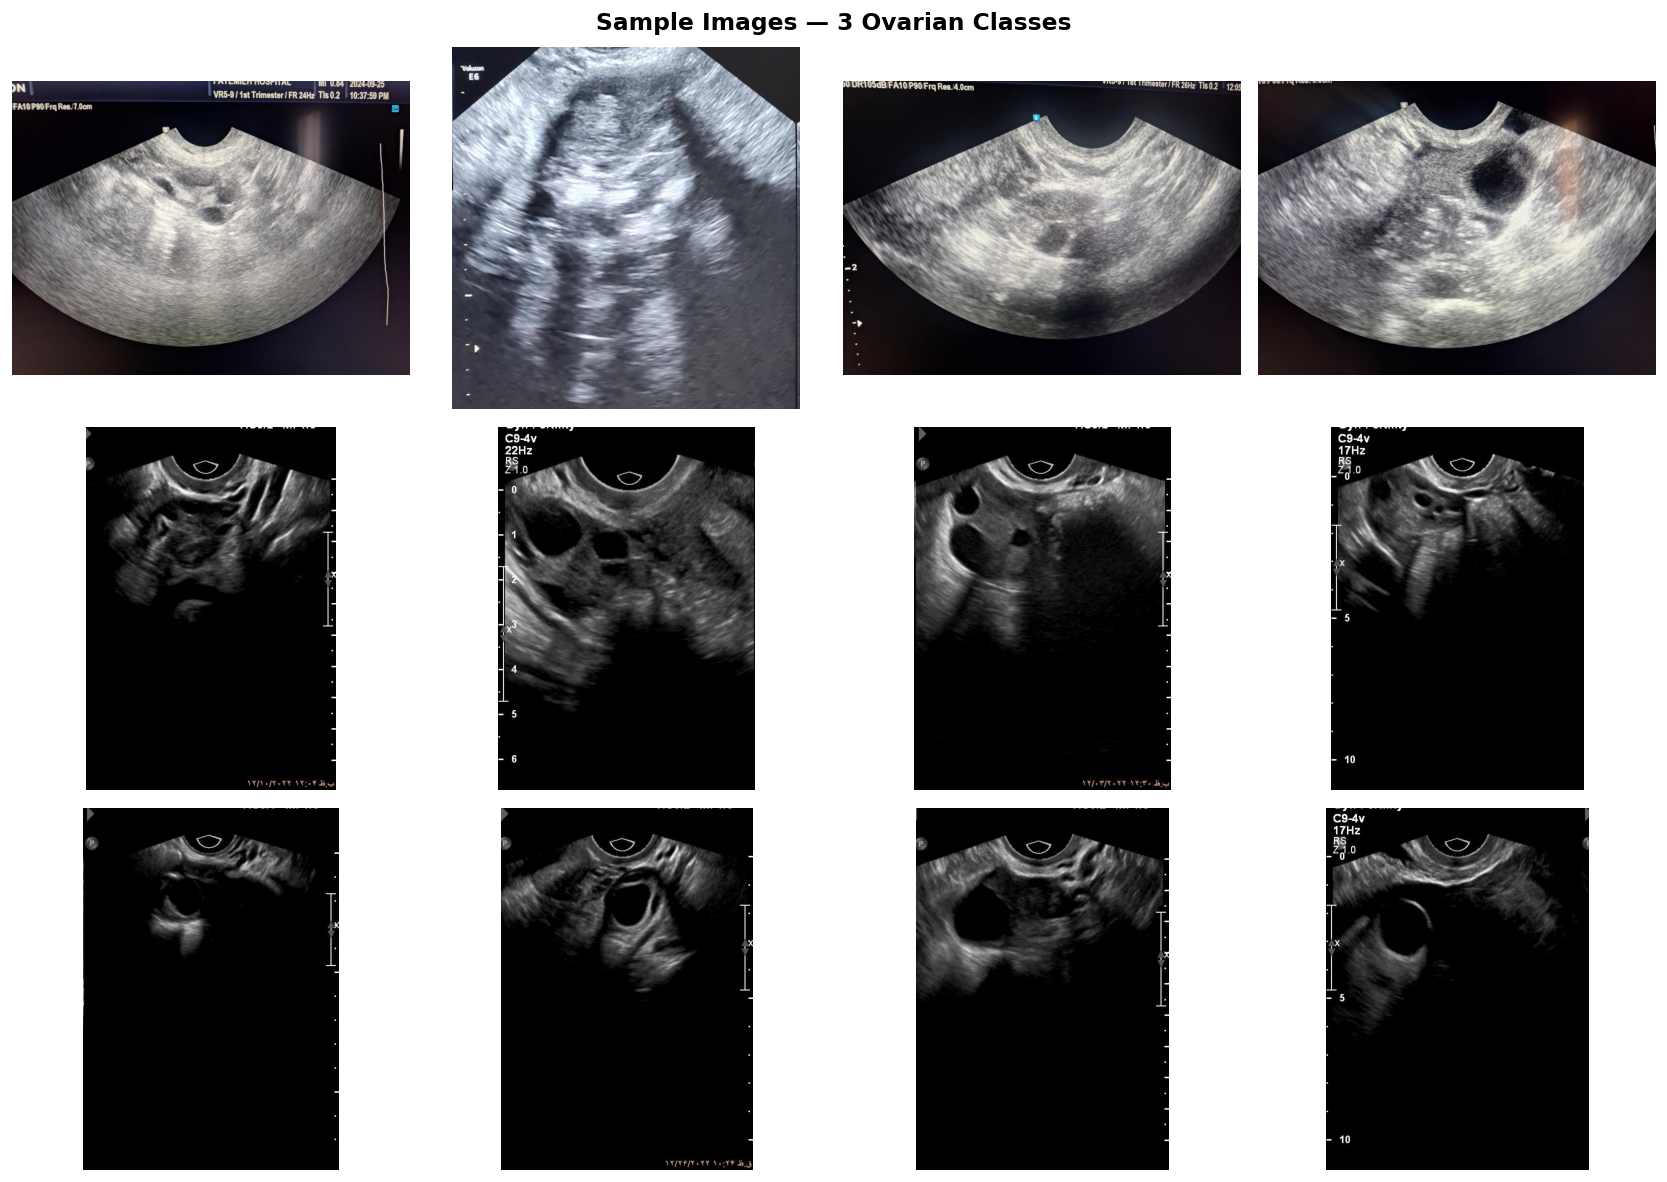

✅ Sample images visualised


In [6]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_path)[:4]

    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = plt.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=11,
                                   fontweight='bold', rotation=90)

plt.suptitle('Sample Images — 3 Ovarian Classes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('outputs/plots', exist_ok=True)
plt.savefig('outputs/plots/B4_00_sample_images.png', bbox_inches='tight')
plt.show()
print('Sample images visualised')

### Cell 6 — Compute Class Weights

In [7]:
import numpy as np

# Count training samples per class
class_counts = {}
for cls in CLASSES:
    path = os.path.join(TRAIN_DIR, cls)
    class_counts[cls] = len(os.listdir(path))

total_train = sum(class_counts.values())
n_classes = len(CLASSES)

# Compute weights
class_indices = train_generator.class_indices
class_weights = {}
for cls, idx in class_indices.items():
    count = class_counts[cls]
    weight = total_train / (n_classes * count)
    class_weights[idx] = weight

print('=== CLASS WEIGHTS ===')
for cls, idx in class_indices.items():
    print(f'  {cls:20s} (index {idx}): count={class_counts[cls]:3d} weight={class_weights[idx]:.3f}')

print(f'\nClass weights computed')
print(f'   Normal gets higher weight — fewer samples')

=== CLASS WEIGHTS ===
  Dominant_Follicle    (index 0): count=101 weight=0.696
  Normal               (index 1): count= 29 weight=2.425
  PCO                  (index 2): count= 81 weight=0.868

✅ Class weights computed
   Normal gets higher weight — fewer samples


### Cell 7 — Build MobileNetV2 Model

In [8]:
# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Phase 1 — freeze base
base_model.trainable = False

# Build model
inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001))(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(0.001))(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(3, activation='softmax')(x)  # 3 classes

model = Model(inputs, outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc')]
)

model.summary()
print('\nModel built — 3 class output')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,203 (9.99 MB)

 Trainable params: 361,219 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


✅ Model built — 3 class output


### Cell 8 — Callbacks & Phase 1 Training

In [9]:
# Callbacks
callback_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'outputs/checkpoints/best_model_phase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print('Phase 1 Training — Frozen MobileNetV2...')
history1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callback_list,
    class_weight=class_weights,
    verbose=1
)

print('Phase 1 Training complete')

🚀 Phase 1 Training — Frozen MobileNetV2...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3416 - auc: 0.5543 - loss: 1.9855
Epoch 1: val_accuracy improved from None to 0.73333, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.3714 - auc: 0.5860 - loss: 1.8863 - val_accuracy: 0.7333 - val_auc: 0.8905 - val_loss: 1.2461 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4864 - auc: 0.7062 - loss: 1.6298
Epoch 2: val_accuracy did not improve from 0.73333
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.5048 - auc: 0.7300 - loss: 1.5428 - val_accuracy: 0.7111 - val_auc: 0.8784 - val_loss: 1.1753 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.5909 - auc: 0.7902 - loss: 1.2942
Epoch 3: val_accuracy improved from 0.73333 to 0.77778, saving model to best_model_phase1.keras

Epoch 3: finishe

### Cell 9 — Plot Training Curves

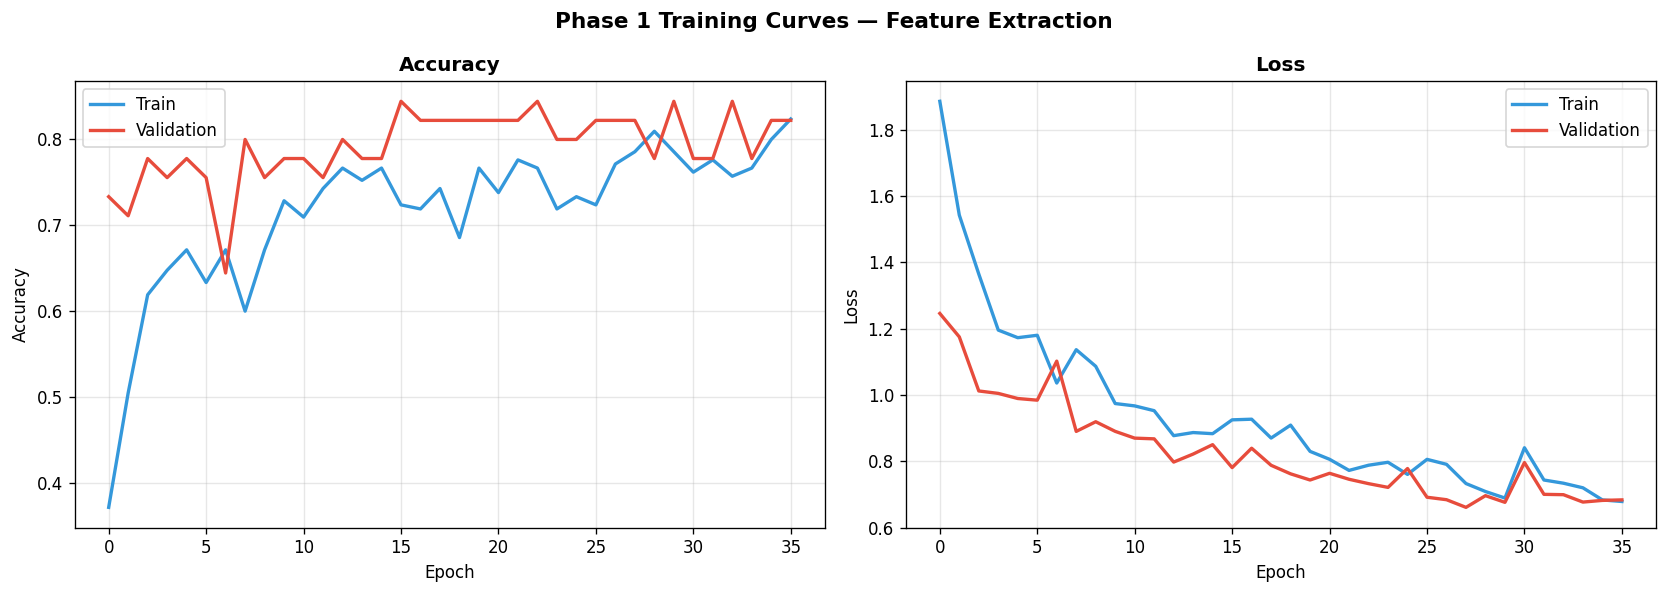

✅ Training curves plotted


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history1.history['accuracy'],
             label='Train', color='#3498db', linewidth=2)
axes[0].plot(history1.history['val_accuracy'],
             label='Validation', color='#e74c3c', linewidth=2)
axes[0].set_title('Accuracy', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history1.history['loss'],
             label='Train', color='#3498db', linewidth=2)
axes[1].plot(history1.history['val_loss'],
             label='Validation', color='#e74c3c', linewidth=2)
axes[1].set_title('Loss', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Phase 1 Training Curves — Feature Extraction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('outputs/plots', exist_ok=True)
plt.savefig('outputs/plots/B4_01_training_curves_phase1.png', bbox_inches='tight')
plt.show()
print('Training curves plotted')

### Cell 10 — Phase 2 Fine-tuning

In [11]:
# Unfreeze last 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Count trainable layers
trainable = sum([l.trainable for l in base_model.layers])
print(f'Trainable layers in base: {trainable}/{len(base_model.layers)}')

# Recompile with very low learning rate
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc')]
)

# New callbacks for phase 2
callback_list2 = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'outputs/checkpoints/best_model_phase2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print('\nPhase 2 Training — Fine-tuning last 30 layers...')
history2 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callback_list2,
    class_weight=class_weights,
    verbose=1
)

print('Phase 2 Fine-tuning complete')

Trainable layers in base: 30/154

🚀 Phase 2 Training — Fine-tuning last 30 layers...
Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.4145 - auc: 0.6139 - loss: 1.4172
Epoch 1: val_accuracy improved from None to 0.84444, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.3905 - auc: 0.6005 - loss: 1.4615 - val_accuracy: 0.8444 - val_auc: 0.9606 - val_loss: 0.6582 - learning_rate: 1.0000e-05
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4741 - auc: 0.6944 - loss: 1.2077
Epoch 2: val_accuracy did not improve from 0.84444
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.4429 - auc: 0.6547 - loss: 1.3008 - val_accuracy: 0.8222 - val_auc: 0.9606 - val_loss: 0.6551 - learning_rate: 1.0000e-05
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.5544 - auc: 0.7185 - loss: 1.2038
Epoch 3: val_accuracy did not improve from 0.84444
14/14 ━━━

### Cell 11 — Evaluate on Test Set

In [12]:
# Reset test generator
test_generator.reset()

# Predictions
y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

# Class labels
class_labels = ['Dominant_Follicle', 'Normal', 'PCO']

print('=== CNN TEST SET EVALUATION ===')
print(f'Total test images: {len(y_true)}')
print(f'\nClassification Report:')
print(classification_report(y_true, y_pred,
      target_names=class_labels))

# Overall metrics
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred)
print(f'Overall Accuracy : {acc:.4f}')

# Per-class AUC (one-vs-rest)
from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
auc_scores = []
for i in range(3):
    auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
    auc_scores.append(auc)
    print(f'AUC ({class_labels[i]:20s}): {auc:.4f}')

print(f'\nMacro AUC: {np.mean(auc_scores):.4f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 6s/step
=== CNN TEST SET EVALUATION ===
Total test images: 46

Classification Report:
                   precision    recall  f1-score   support

Dominant_Follicle       0.94      0.77      0.85        22
           Normal       0.75      0.86      0.80         7
              PCO       0.70      0.82      0.76        17

         accuracy                           0.80        46
        macro avg       0.80      0.82      0.80        46
     weighted avg       0.82      0.80      0.81        46

Overall Accuracy : 0.8043
AUC (Dominant_Follicle   ): 0.9527
AUC (Normal              ): 0.9707
AUC (PCO                 ): 0.8661

Macro AUC: 0.9298


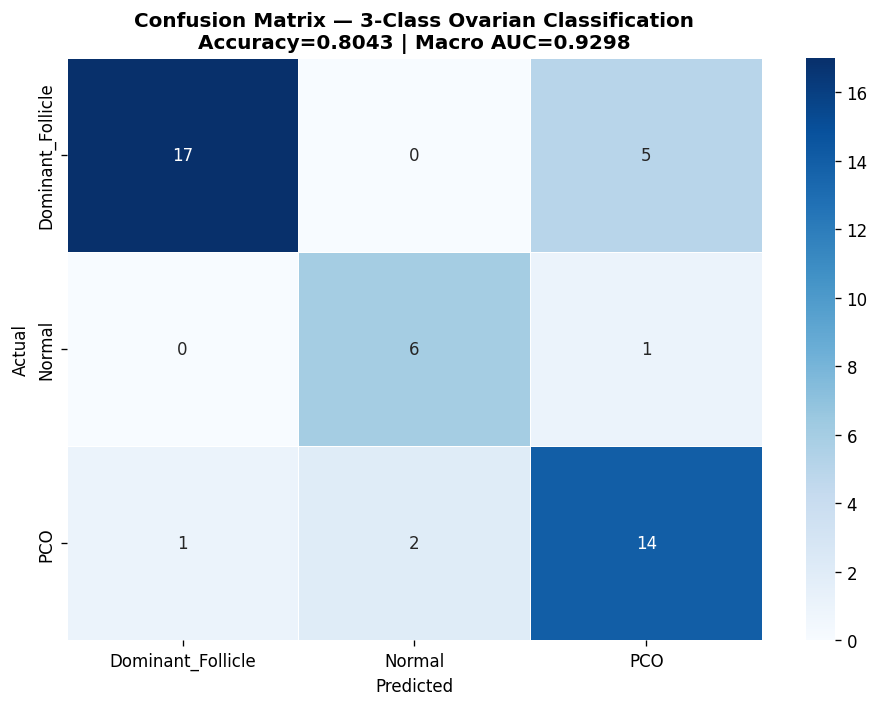

✅ Confusion matrix plotted


In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels,
            linewidths=0.5)
plt.title('Confusion Matrix — 3-Class Ovarian Classification\n'
          f'Accuracy={acc:.4f} | Macro AUC={np.mean(auc_scores):.4f}',
          fontweight='bold', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('outputs/plots/B4_02_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Confusion matrix plotted')

In [15]:
# Save final model — matches the sibling notebooks, which all write straight into
# ../artifacts/. Re-running this overwrites the shipped pmos_cnn_final.keras.
model.save('../artifacts/pmos_cnn_final.keras')
print('Model saved to ../artifacts/pmos_cnn_final.keras')

✅ Model saved as pmos_cnn_final.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded


In [1]:
print('=== CNN MODEL CONFIGURATION SUMMARY ===')
print()
print('Dataset:')
print(f'  Normal           : 42 images')
print(f'  PCO              : 117 images')
print(f'  Dominant Follicle: 145 images')
print(f'  Total            : 304 images')
print(f'  Train/Val/Test   : 210 / 45 / 46')
print()
print('Base Model:')
print(f'  Architecture     : MobileNetV2')
print(f'  Pretrained on    : ImageNet (1.2M images)')
print(f'  Input size       : 224 × 224 × 3')
print(f'  Phase 1          : Base frozen, top layers trained')
print(f'  Phase 2          : Last 30 layers unfrozen, fine-tuned')
print()
print('Custom Layers:')
print(f'  GlobalAveragePooling2D')
print(f'  Dense(256, relu) + L2(0.001)')
print(f'  Dropout(0.5)     ← 50% neurons dropped')
print(f'  Dense(128, relu) + L2(0.001)')
print(f'  Dropout(0.3)     ← 30% neurons dropped')
print(f'  Dense(3, softmax) ← 3 class output')
print()
print('Data Augmentation (training only):')
print(f'  Rotation range   : ±15°')
print(f'  Horizontal flip  : Yes')
print(f'  Zoom range       : ±10%')
print(f'  Width shift      : ±10%')
print(f'  Height shift     : ±10%')
print(f'  Brightness range : 0.8 - 1.2')
print(f'  Test augmentation: None (original images only)')
print()
print('Training Configuration:')
print(f'  Optimizer        : Adam')
print(f'  Phase 1 LR      : 0.001')
print(f'  Phase 2 LR      : 0.00001')
print(f'  Loss             : Categorical Crossentropy')
print(f'  Batch size       : 16')
print(f'  Max epochs       : 50 (Phase 1), 30 (Phase 2)')
print(f'  Early stopping   : patience=8')
print(f'  LR reduction     : ReduceLROnPlateau factor=0.5')
print(f'  Class weights    : Yes (Normal=2.425, DF=0.696, PCO=0.868)')
print()
print('Final Test Results:')
print(f'  Overall Accuracy : 80.43%')
print(f'  Macro AUC        : 0.9298')
print(f'  Macro F1         : 0.80')
print(f'  Dominant Follicle: Precision=0.94, Recall=0.77, F1=0.85')
print(f'  Normal           : Precision=0.75, Recall=0.86, F1=0.80')
print(f'  PCO              : Precision=0.70, Recall=0.82, F1=0.76')
print()
print('Benchmark Comparison:')
print(f'  Published paper (ResNet18) : 76.2% accuracy, 78.2% macro F1')
print(f'  Our model (MobileNetV2)    : 80.4% accuracy, 80.0% macro F1')
print()
print('Note: While our results are higher than the reported benchmark,')
print('direct comparison should be made cautiously. Differences in')
print('dataset splitting strategy, preprocessing pipeline, augmentation')
print('parameters, and evaluation methodology between studies may')
print('contribute to observed performance differences.')

=== CNN MODEL CONFIGURATION SUMMARY ===

Dataset:
  Normal           : 42 images
  PCO              : 117 images
  Dominant Follicle: 145 images
  Total            : 304 images
  Train/Val/Test   : 210 / 45 / 46

Base Model:
  Architecture     : MobileNetV2
  Pretrained on    : ImageNet (1.2M images)
  Input size       : 224 × 224 × 3
  Phase 1          : Base frozen, top layers trained
  Phase 2          : Last 30 layers unfrozen, fine-tuned

Custom Layers:
  GlobalAveragePooling2D
  Dense(256, relu) + L2(0.001)
  Dropout(0.5)     ← 50% neurons dropped
  Dense(128, relu) + L2(0.001)
  Dropout(0.3)     ← 30% neurons dropped
  Dense(3, softmax) ← 3 class output

Data Augmentation (training only):
  Rotation range   : ±15°
  Horizontal flip  : Yes
  Zoom range       : ±10%
  Width shift      : ±10%
  Height shift     : ±10%
  Brightness range : 0.8 - 1.2
  Test augmentation: None (original images only)

Training Configuration:
  Optimizer        : Adam
  Phase 1 LR      : 0.001
  Phase 2